# Darts - Temporal Fusion Transformer(TFT)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from darts import TimeSeries
import darts.metrics as metrics
from darts.models import TFTModel
from darts.dataprocessing.transformers import Scaler, MissingValuesFiller

import torch
from pytorch_lightning.callbacks import EarlyStopping

/var/www/html/cours/brief15_prediction_bourse/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file = "datas/magnific7_1day.pkl"
series_dict = pd.read_pickle(file)

### Détection des trous dans les dates

In [3]:
for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    full_series = pd.date_range(start=df.index.min(), end=df.index.max(), freq="B")
    missing_dates = full_series.difference(df.index)

    print(f"{name}: {len(missing_dates)} dates manquantes")


APPLE: 143 dates manquantes
MICROSOFT: 143 dates manquantes
AMAZON: 143 dates manquantes
ALPHABET: 143 dates manquantes
NVIDIA: 143 dates manquantes
META: 123 dates manquantes
TESLA: 139 dates manquantes


### Conversion des 7 dataframes en time series

In [4]:
filler = MissingValuesFiller()

all_series = []
all_past_covariates = []

for name, df in series_dict.items():
    df.index = pd.to_datetime(df.index)

    ts = TimeSeries.from_dataframe(df, value_cols='close', fill_missing_dates=True, freq='B')
    ts = filler.transform(ts)
    all_series.append(ts)

    ts_past_covariates = TimeSeries.from_dataframe(df, value_cols=['open', 'high', 'low', 'volume'], fill_missing_dates=True, freq='B')
    ts_past_covariates = filler.transform(ts_past_covariates)
    all_past_covariates.append(ts_past_covariates)


### Séparation du jeu de données

In [5]:
train_series = []
val_series = []
train_past_covariates = []
val_past_covariates = []

for ts_close, ts_cov in zip(all_series, all_past_covariates):
    train_close, val_close = ts_close.split_before(0.8)
    train_series.append(train_close)
    val_series.append(val_close)

    train_cov, val_cov = ts_cov.split_before(0.8)
    train_past_covariates.append(train_cov)
    val_past_covariates.append(val_cov)

### Normalisation des données

In [6]:
scalers = []
train_series_scaled = []
val_series_scaled = []
close_scalers = []
train_past_covariates_scaled = []
val_past_covariates_scaled = []
past_cov_scalers = []

for train, val in zip(train_series, val_series):
    close_scaler = Scaler(StandardScaler())
    train_scaled = close_scaler.fit_transform(train)
    val_scaled = close_scaler.transform(val)

    scalers.append(close_scaler)
    train_series_scaled.append(train_scaled)
    val_series_scaled.append(val_scaled)

    past_cov_scaler = Scaler(StandardScaler())
    train_cov_scaled = past_cov_scaler.fit_transform(train)
    val_cov_scaled = past_cov_scaler.transform(val)

    close_scalers.append(past_cov_scaler)
    train_past_covariates_scaled.append(train_cov_scaled)
    val_past_covariates_scaled.append(val_cov_scaled)

### Vérification Cuda

In [7]:
if torch.cuda.is_available():
    print(f"CUDA est disponible ! Nombre de GPUs : {torch.cuda.device_count()}")
    gpu_devices = [0]
else:
    print("CUDA n'est pas disponible. Utilisation du CPU.")
    gpu_devices = 0

CUDA est disponible ! Nombre de GPUs : 1


### Implémentation de EarlyStopping

In [8]:
early_stopper = EarlyStopping(
    monitor="val_loss",
    patience=20,
    min_delta=0.05,
    mode='min'
)

pl_trainer_kwargs={
    "callbacks": [
        early_stopper
    ],
    "accelerator": "gpu",
    "devices": gpu_devices
}

## Modèle TFT

In [9]:
model_tft = TFTModel(
    model_name="TFT",
    input_chunk_length=60,
    output_chunk_length=30,
    hidden_size=128,
    lstm_layers=1,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=32, # ou 64 si beaucoup de RAM sur GPU
    n_epochs=100,
    add_relative_index=True,
    likelihood=None,
    random_state=42,
    optimizer_kwargs={"lr": 5e-4},
    force_reset=True,
    log_tensorboard=True,
    pl_trainer_kwargs=pl_trainer_kwargs,
    )

model_tft.fit(
    series=train_series_scaled, 
    past_covariates=train_past_covariates_scaled,
    val_series=val_series_scaled, 
    val_past_covariates=val_past_covariates_scaled,
    verbose=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | 

Epoch 21: 100%|██████████| 679/679 [00:54<00:00, 12.40it/s, v_num=logs, train_loss=0.208, val_loss=11.50]


TFTModel(output_chunk_shift=0, hidden_size=128, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, model_name=TFT, input_chunk_length=60, output_chunk_length=30, batch_size=32, n_epochs=100, random_state=42, optimizer_kwargs={'lr': 0.0005}, force_reset=True, log_tensorboard=True, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x7f5a91de7200>], 'accelerator': 'gpu', 'devices': [0]})

### Evaluation du model

In [18]:
def evaluate_model_historical_forecasts(model, 
                   train_series_scaled, val_series_scaled, target_scaler,
                   train_past_covariates_scaled=None, val_past_covariates_scaled=None, past_cov_scaler=None,
                   forecast_horizon=None):

    """
    Évalue un modèle Darts en utilisant la méthode historical_forecasts()
    sur les séries de validation, en gérant les covariables passées.

    Args:
        model: Le modèle Darts entraîné.
        train_series_scaled: Liste des séries d'entraînement mises à l'échelle (cible).
        val_series_scaled: Liste des séries de validation mises à l'échelle (cible).
        target_scaler: Le scaler utilisé pour les séries cibles (pour la dénormalisation).
        train_past_covariates_scaled: Liste des covariables passées d'entraînement mises à l'échelle (optionnel).
        val_past_covariates_scaled: Liste des covariables passées de validation mises à l'échelle (optionnel).
        past_cov_scaler: Le scaler utilisé pour les covariables passées (pour la dénormalisation, si besoin).
        forecast_horizon: L'horizon de prédiction désiré (n dans predict).
                          Si None, utilise output_chunk_length du modèle.

    Returns:
        pd.DataFrame: Un DataFrame contenant les métriques MAE, RMSE et MAPE
                      pour chaque série évaluée.
        list: Liste des prédictions dénormalisées pour chaque série.
    """

    if forecast_horizon is None:
        forecast_horizon = model.output_chunk_length

    performance = {}
    all_denormalized_predictions = []

    # Vérification de la présence de covariables passées
    use_past_covariates = train_past_covariates_scaled is not None and val_past_covariates_scaled is not None

    # Boucle sur chaque série
    for i in range(len(val_series_scaled)):
        current_train_series = train_series_scaled[i]
        current_val_series = val_series_scaled[i]

        #  Concatenation des séries d'entraînement et de validation
        full_series_for_backtest = current_train_series.append(current_val_series)

        current_past_covariates = None
        if use_past_covariates:
            current_train_past_cov = train_past_covariates_scaled[i]
            current_val_past_cov = val_past_covariates_scaled[i]
            current_past_covariates_for_backtest = current_train_past_cov.append(current_val_past_cov)

        #Définir le pout de départ pour historical_forecasts
        start_val_time = current_val_series.start_time()

        # Prédictions historiques
        try:
            if use_past_covariates:
                predictions_scaled = model.historical_forecasts(
                    series=full_series_for_backtest,
                    past_covariates=current_past_covariates_for_backtest,
                    start=start_val_time,
                    forecast_horizon=forecast_horizon,
                    stride=1,
                    retrain=False,
                    last_points_only=True,
                    verbose=False
                )
            else:
                predictions_scaled = model.historical_forecasts(
                    series=full_series_for_backtest,
                    start=start_val_time,
                    forecast_horizon=forecast_horizon,
                    stride=1,
                    retrain=False,
                    last_points_only=True,
                    verbose=False
                )        
        except Exception as e:
            print(f"Erreur lors de l'évaluation de la série {i}: {e}")
            predictions_scaled = TimeSeries.from_times_and_values(current_val_series.time_index[:0], np.array([]))

        # Dénormalisation des prédictions
        pred = target_scaler.inverse_transform(predictions_scaled)
        actual = target_scaler.inverse_transform(current_val_series)

        #  Alignement des séries sur la période actual 
        pred_aligned = pred.slice_intersect(actual)
        actual_aligned = actual.slice_intersect(pred)

        all_denormalized_predictions.append(pred_aligned)

        #  Calcul des métriques
        if len(actual_aligned) > 0 and len(pred_aligned) > 0:
            mae_value = metrics.mae(actual_aligned, pred_aligned)
            rmse_value = metrics.rmse(actual_aligned, pred_aligned)
            mape_value = metrics.mape(actual_aligned, pred_aligned)
        else:
            mae_value, rmse_value, mape_value = np.nan, np.nan, np.nan

        performance[f'Série {i}'] = {
            "MAE": mae_value,
            "RMSE": rmse_value,
            "MAPE": mape_value
        }
    
    return pd.DataFrame(performance).T, all_denormalized_predictions

In [19]:
perf_df_historical_forecast, all_predictions_fot_plot = evaluate_model_historical_forecasts(
    model_tft,
    train_series_scaled,
    val_series_scaled,
    close_scaler,
    train_past_covariates_scaled,
    val_past_covariates_scaled,
    past_cov_scaler,
    forecast_horizon=model_tft.output_chunk_length
)
print(perf_df_historical_forecast) 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
GPU available: True (cuda), used: True
TPU available

                MAE        RMSE       MAPE
Série 0   64.027471   78.933948  17.583842
Série 1   61.665398   75.523168  17.537507
Série 2   30.964214   39.819772  17.415681
Série 3   48.860179   63.520038  15.872308
Série 4  624.562605  887.466305  52.415546
Série 5   73.612586   96.625043  74.405617
Série 6   45.476280   58.630872  19.537509


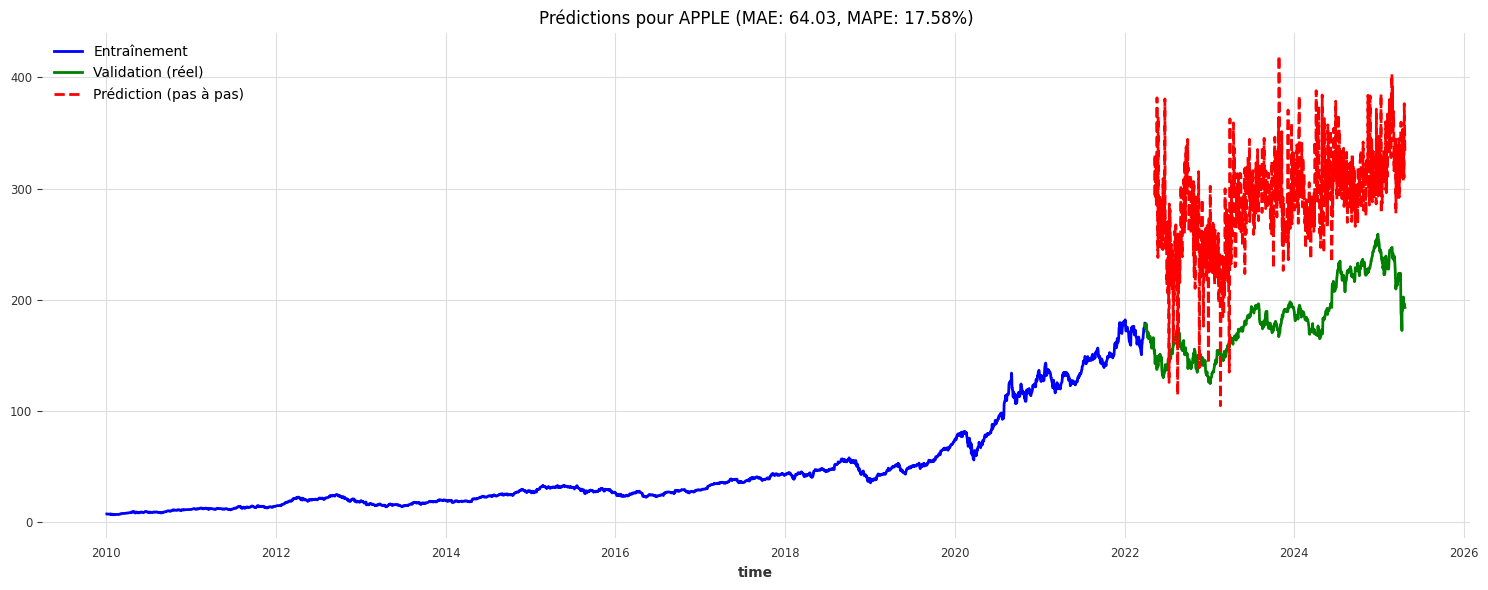

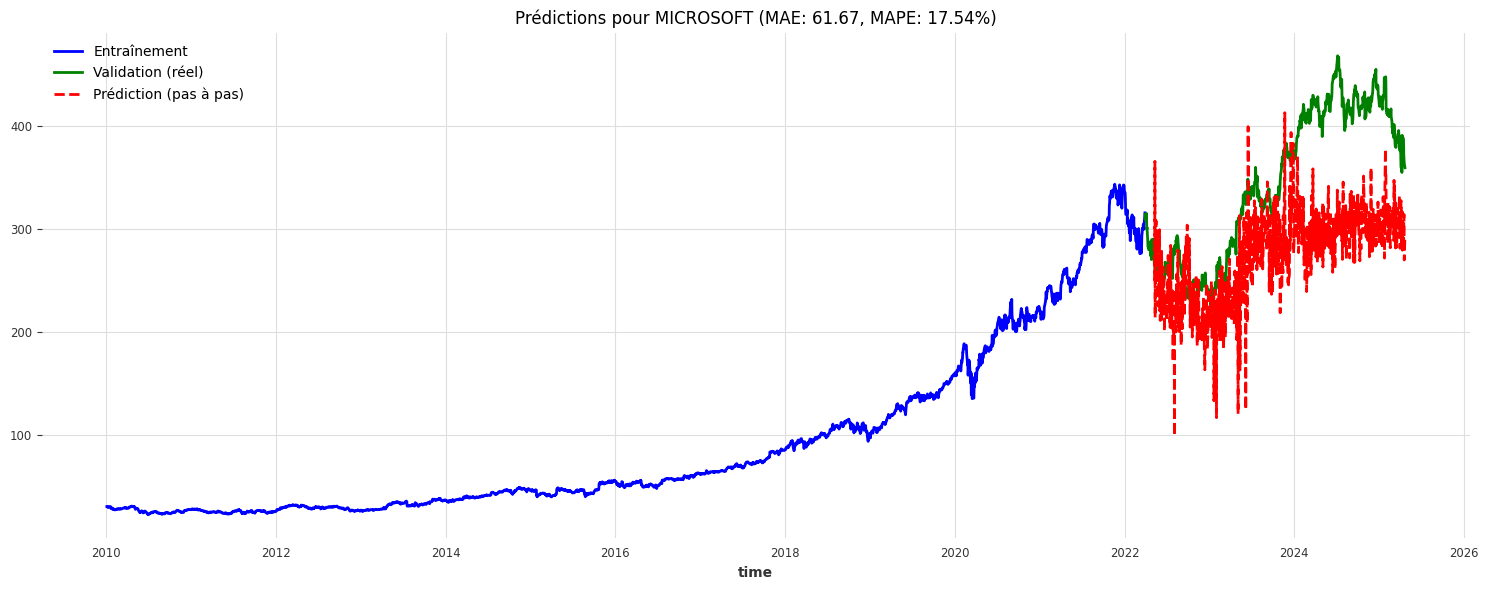

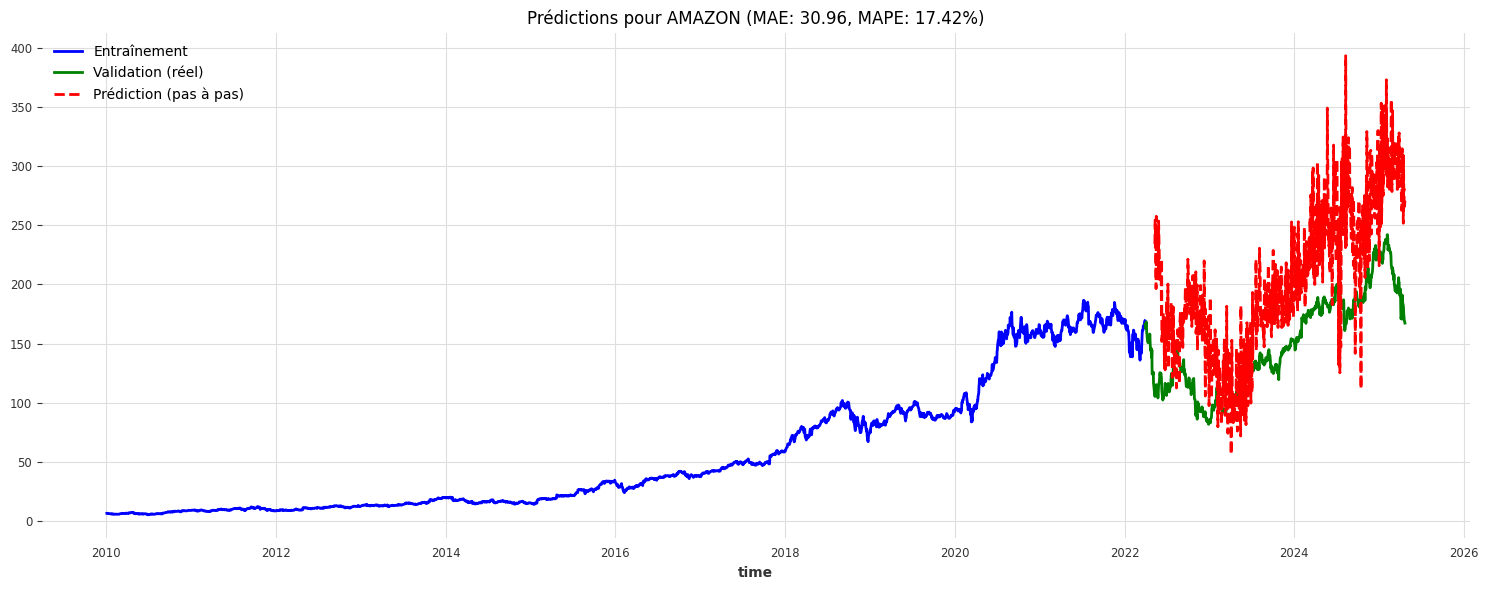

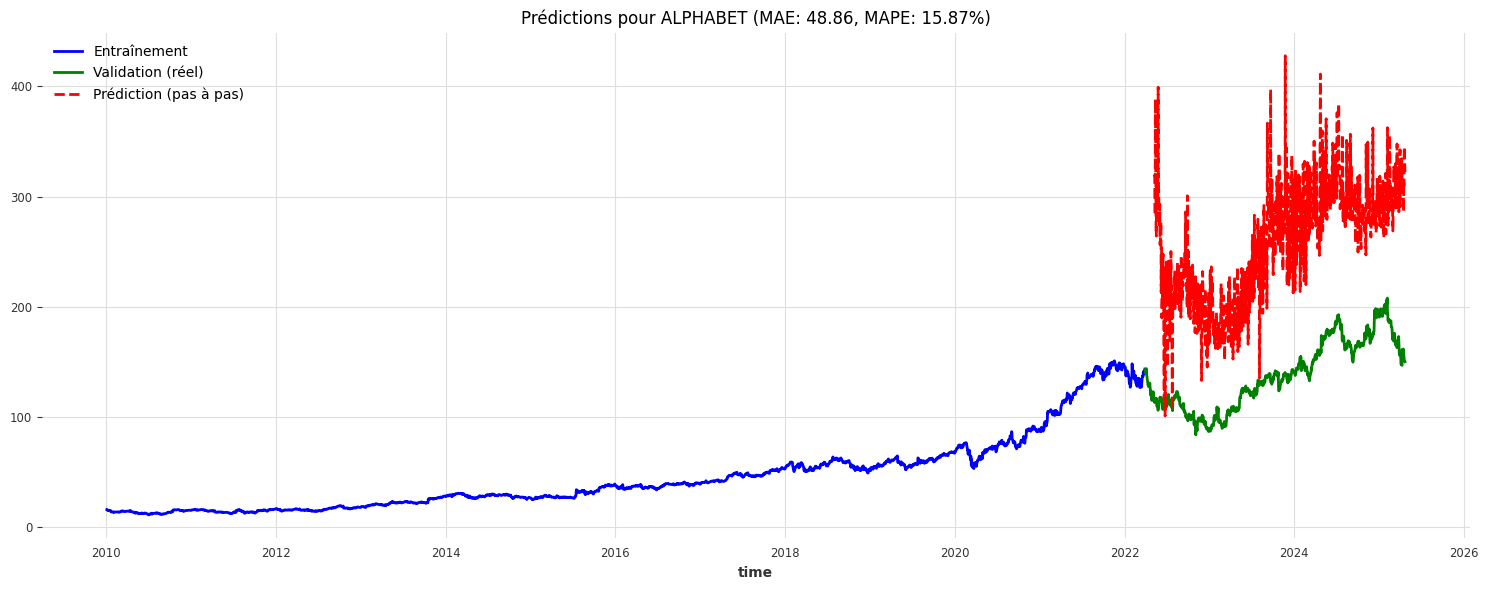

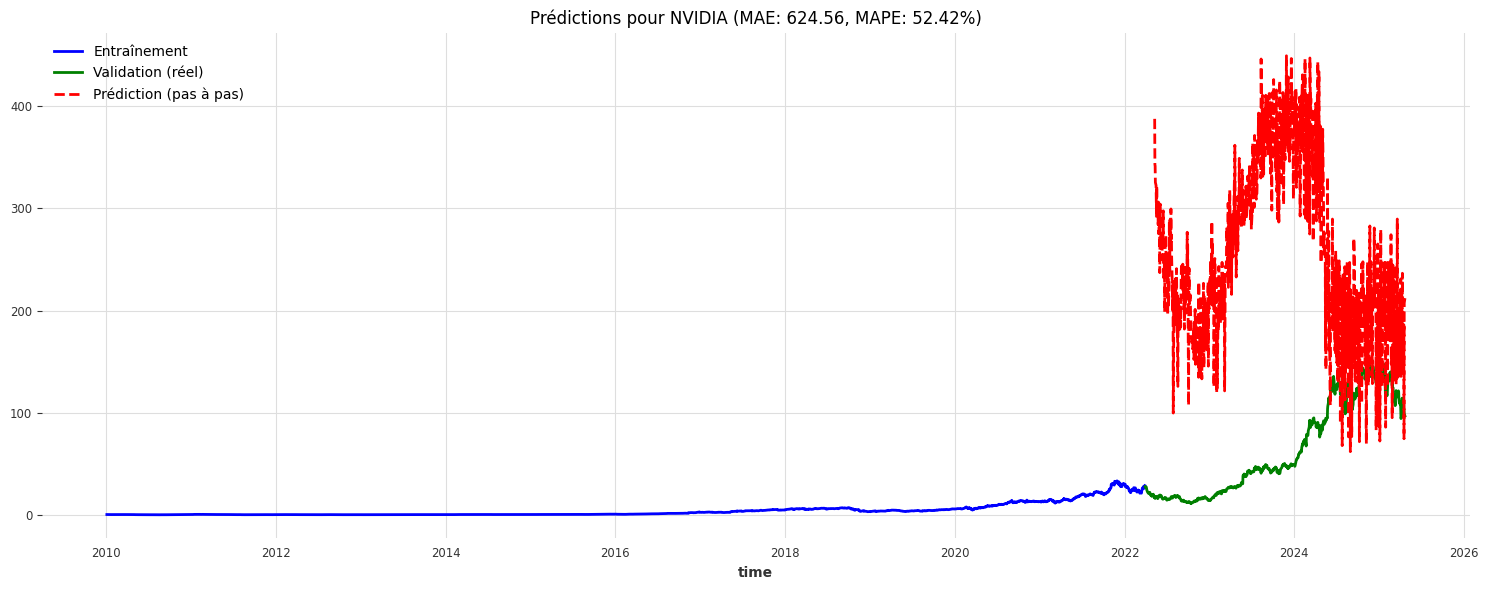

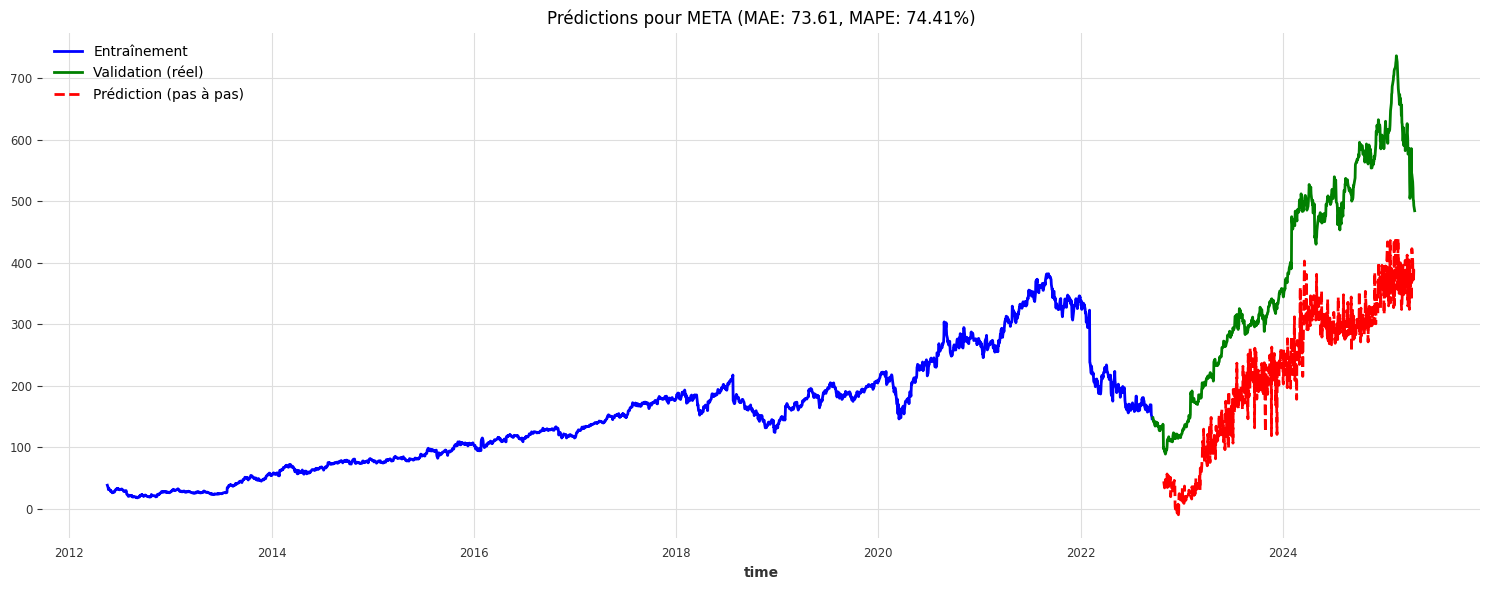

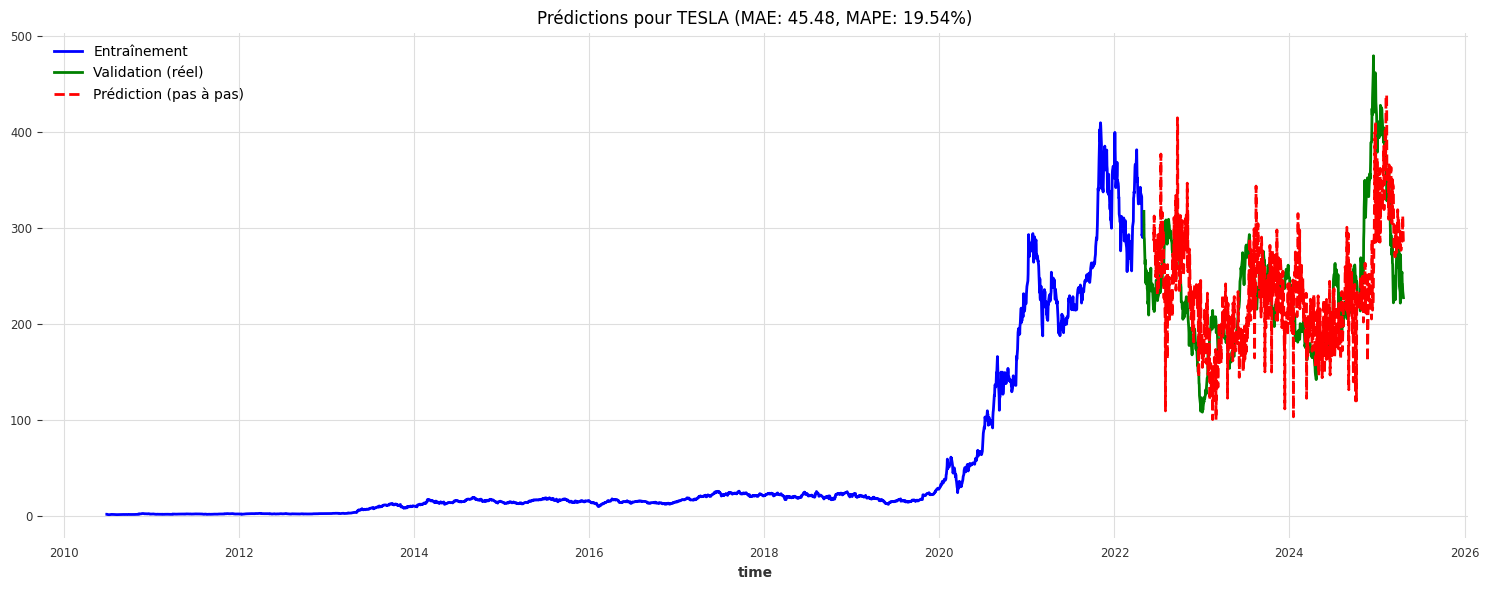

In [20]:
company_names = ['APPLE', 'MICROSOFT', 'AMAZON', 'ALPHABET', 'NVIDIA', 'META', 'TESLA']

# Pour chaque série (entreprise)
for idx in range(len(train_series)):
    # Récupérer les données d'entraînement et de validation
    train_data = train_series[idx]
    val_data = val_series[idx]
    
    pred_data = all_predictions_fot_plot[idx]

    mae_val = perf_df_historical_forecast.loc[f'Série {idx}', 'MAE']
    mape_val = perf_df_historical_forecast.loc[f'Série {idx}', 'MAPE']

    # Créer une nouvelle figure pour chaque entreprise
    plt.figure(figsize=(15, 6))

    # Tracer les séries temporelles
    train_data.plot(label='Entraînement', color='blue')
    val_data.plot(label='Validation (réel)', color='green')
    pred_data.plot(label='Prédiction (pas à pas)', color='red', linestyle='--')

    # Ajouter titre et légende avec métriques
    plt.title(f'Prédictions pour {company_names[idx]} (MAE: {mae_val:.2f}, MAPE: {mape_val:.2f}%)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()